In [1]:
import numpy as np
x = np.array([[1, 2], [3, 4]])
y = np.array([[5, 6], [7, 8]])

a = np.hstack((x,y))
print(a)

b = np.vstack((x,y))
print(b)

xf = x.flatten()
yf = y.flatten()

af = np.hstack((xf, yf))
print(af)

bf = np.vstack((xf, yf))
print(bf)

cf = af.reshape(2,4)
print(cf)

[[1 2 5 6]
 [3 4 7 8]]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[1 2 3 4 5 6 7 8]
[[1 2 3 4]
 [5 6 7 8]]
[[1 2 3 4]
 [5 6 7 8]]


In [ ]:
import numpy as np
np.random.seed(42)
num_samples = 10


features_a = np.random.randn(num_samples, 2) * 0.5 + np.array([0, 0])  # Cluster around (0,0)
features_b = np.random.randn(num_samples, 2) * 0.5 + np.array([3, 3])  # Cluster around (3,3)


labels_a = np.full((num_samples, 1), "a", dtype=object)
labels_b = np.full((num_samples, 1), "b", dtype=object)


data_a = np.hstack((features_a, labels_a))
data_b = np.hstack((features_b, labels_b))


knn_data = np.vstack((data_a, data_b))


np.random.seed(42)
np.random.shuffle(knn_data)


knn_data


array([[0.24835707650561634, -0.06913215058559233, 'a'],
       [3.4112724560515946, 2.389578175014489, 'b'],
       [2.6991466938853015, 3.926139092254469, 'b'],
       [0.32384426905034625, 0.7615149282040127, 'a'],
       [-0.5064155601672119, 0.15712366629763694, 'a'],
       [-0.23170884640623113, -0.23286487678512843, 'a'],
       [3.033764102343962, 2.287625906893272, 'b'],
       [0.7896064077536957, 0.3837173645764544, 'a'],
       [3.104431797502378, 2.020164938060112, 'b'],
       [2.993251387631033, 2.4711445355220496, 'b'],
       [2.4245032112888487, 3.1878490091728358, 'b'],
       [-0.11707668736166799, -0.11706847847459027, 'a'],
       [-0.45401203776060545, -0.7061518506676457, 'a'],
       [2.3359069755507846, 3.0984306179345618, 'b'],
       [-0.23473719296747605, 0.27128002179298233, 'a'],
       [2.7278086377374087, 3.055461294854933, 'b'],
       [-0.8624589162565164, -0.28114376462048635, 'a'],
       [3.732824384460777, 2.887111849756732, 'b'],
       [2.69968

In [ ]:
pip install matplotlib

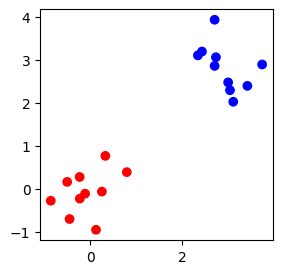

In [12]:
import matplotlib.pyplot as plt

x = knn_data[:,0]
y = knn_data[:,1]
l = knn_data[:,2]

color_map = {'a': 'red', 'b': 'blue'}
colors = [color_map[label] for label in l]
plt.figure(figsize=(3, 3))
plt.scatter(x, y, c=colors, label=l)


In [24]:
np.random.seed(42)
new_point = np.random.rand(2)
print(new_point)

[0.37454012 0.95071431]


In [28]:
k = 3
distances = []

# Berechnung der euklidischen Distanzen
for sample in knn_data:
    x_sample, y_sample = float(sample[0]), float(sample[1])  # Umwandlung in Float
    label = sample[2]  # Klassenlabel
    
    distance = np.sqrt((x_sample - new_point[0]) ** 2 + (y_sample - new_point[1]) ** 2)
    distances.append([distance, label])

distances

[[np.float64(1.0276229639419852), 'a'],
 [np.float64(3.360367914410206), 'b'],
 [np.float64(3.775837441538992), 'b'],
 [np.float64(0.19587361716204185), 'a'],
 [np.float64(1.1856934732306859), 'a'],
 [np.float64(1.3298110733347432), 'a'],
 [np.float64(2.9763744424904757), 'b'],
 [np.float64(0.7026845353606223), 'a'],
 [np.float64(2.9318992531679697), 'b'],
 [np.float64(3.0280945808961373), 'b'],
 [np.float64(3.0343237069697095), 'b'],
 [np.float64(1.175519952975227), 'a'],
 [np.float64(1.852485934815345), 'a'],
 [np.float64(2.9085469398590926), 'b'],
 [np.float64(0.9126060430466373), 'a'],
 [np.float64(3.1571874520476797), 'b'],
 [np.float64(1.7457493863698397), 'a'],
 [np.float64(3.876558867674553), 'b'],
 [np.float64(3.0048889912204846), 'b'],
 [np.float64(1.9241343702356644), 'a']]

In [29]:
nearest_neighbors = []
for _ in range(k):
    min_distance = float("inf")
    min_label = None
    min_index = -1
    
    for i in range(len(distances)):
        if distances[i][0] < min_distance:
            min_distance = distances[i][0]
            min_label = distances[i][1]
            min_index = i
    
    # Füge den kleinsten gefundenen Wert der Liste hinzu
    nearest_neighbors.append(min_label)
    
    # Entferne den bereits gewählten Punkt aus der Liste (damit er nicht doppelt gewählt wird)
    distances.pop(min_index)

# Bestimmen der häufigsten Klasse
count_a = 0
count_b = 0

for label in nearest_neighbors:
    if label == "a":
        count_a += 1
    elif label == "b":
        count_b += 1

if count_a > count_b:
    predicted_class = "a"
else:
    predicted_class = "b"

# Ausgabe der Ergebnisse
new_point, predicted_class

(array([0.37454012, 0.95071431]), 'a')